# Task 1: News Topic Classifier Using BERT
**DevelopersHub Corporation — AI/ML Engineering Internship (Phase 2)**

**Objective:** Fine-tune `bert-base-uncased` on the AG News dataset to classify news headlines into 4 topic categories (World, Sports, Business, Sci/Tech), evaluate with Accuracy & F1-score, and deploy with Gradio.


In [1]:
# Cell 1: Install required libraries
!pip install -q transformers datasets evaluate accelerate gradio scikit-learn
!pip uninstall -y torchvision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


## Step 1: Load Dataset (AG News, from Hugging Face Datasets)

In [2]:
# Cell 2: Load Dataset
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")
print(dataset)

# Labels: 0=World, 1=Sports, 2=Business, 3=Sci/Tech
label_names = ["World", "Sports", "Business", "Sci/Tech"]
print(dataset["train"][0])

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


## Step 2: Tokenize and Preprocess

In [3]:
# Cell 3: Tokenization
from transformers import AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=64)

# Using a subset for faster training on Colab's free GPU.
# Increase these numbers (or use full dataset) for higher accuracy if you have time/compute.
train_dataset = dataset["train"].shuffle(seed=42).select(range(8000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(2000))

train_dataset = train_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.map(tokenize_fn, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train size: 8000
Test size: 2000


## Step 3: Load Pre-trained BERT Model for Fine-Tuning

In [4]:
# Cell 4: Load Model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Step 4: Define Evaluation Metrics (Accuracy & F1-score)

In [5]:
# Cell 5: Metrics
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

## Step 5: Fine-tune BERT

In [6]:
# Cell 6: Training
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./bert_news_classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.278479,0.305003,0.904000,0.903965
2,0.229678,0.296615,0.912500,0.912408


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1000, training_loss=0.3088502740859985, metrics={'train_runtime': 226.2205, 'train_samples_per_second': 70.727, 'train_steps_per_second': 4.42, 'total_flos': 526231560192000.0, 'train_loss': 0.3088502740859985, 'epoch': 2.0})

## Step 6: Evaluate the Model

In [7]:
# Cell 7: Evaluation
results = trainer.evaluate()
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.229678,0.296615,2,0.912500,0.912408


{'eval_loss': 0.29661473631858826, 'eval_accuracy': 0.9125, 'eval_f1': 0.9124080139122032}


## Step 7: Visualization — Confusion Matrix

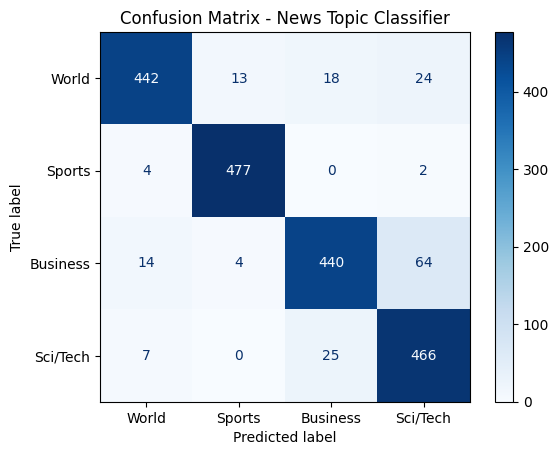

In [8]:
# Cell 8: Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch

preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - News Topic Classifier")
plt.show()

## Step 8: Save the Fine-tuned Model

In [9]:
# Cell 9: Save Model
model.save_pretrained("./bert_news_classifier_final")
tokenizer.save_pretrained("./bert_news_classifier_final")
print("Model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


## Step 9: Deploy with Gradio (Live Interaction)

In [ ]:
# Cell 10: Deploy with Gradio
import gradio as gr

device = next(model.parameters()).device  # find where the model currently is (CPU or GPU)

def classify_news(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    inputs = {k: v.to(device) for k, v in inputs.items()}  # move inputs to same device as model
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
    pred = torch.argmax(probs).item()
    confidence = probs[pred].item()
    return f"{label_names[pred]} (confidence: {confidence:.2%})"

demo = gr.Interface(
    fn=classify_news,
    inputs=gr.Textbox(lines=3, placeholder="Enter a news headline..."),
    outputs="text",
    title="News Topic Classifier (BERT)",
    description="Fine-tuned BERT model classifying news headlines into World, Sports, Business, or Sci/Tech."
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6335f3fabe82dcbc8e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


## Final Summary / Insights

- Fine-tuned `bert-base-uncased` on a subset of the AG News dataset (8,000 train / 2,000 test samples) for 2 epochs.
- Evaluated using **Accuracy** and **weighted F1-score**.
- Visualized model performance with a confusion matrix across the 4 classes.
- Deployed the model as a live web app using **Gradio**, allowing real-time headline classification.
- For improved accuracy: increase the training subset size, number of epochs, or use the full AG News dataset (120,000 train samples) if more compute/time is available.

**Skills Gained:** NLP using Transformers, Transfer Learning & Fine-tuning, Evaluation metrics for text classification, Lightweight model deployment.
